In [18]:
# Dave langer's data set
# Lets try to do a excercise with Random Forest Classifier

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings    
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder




In [19]:
train = pd.read_csv('adult_train.csv')
test = pd.read_csv('adult_test.csv')

In [20]:
train['Sex'].replace({'Male': 1,'Female' : 0}, inplace = True)
train.drop('Fnlwgt', axis = 1, inplace = True)

In [21]:
#do we have to encode both numeric and sategorical columns for random forest?
categorical_columns = train.select_dtypes(exclude = np.number).columns.tolist()
numerical_columns = train.select_dtypes(include = np.number).columns.tolist()
le = LabelEncoder()
for col in categorical_columns:
    train[col] = le.fit_transform(train[col])




In [5]:
y = train['Label']
X = train.drop('Label', axis = 1)



In [7]:
rf_clasifier = RandomForestClassifier(n_estimators = 100, oob_score = True, random_state = 42)
rf_clasifier.fit(X,y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [8]:
print(f'Train --> OOB Score  :  {rf_clasifier.oob_score_ : 4f}')       

Train --> OOB Score  :   0.814398


In [10]:
# What is the accuracy on the training data?
print(f'Training data accuracy: {rf_clasifier.score(X, y):.4f}')

Training data accuracy: 0.9778


In [13]:
# Get the out-of-bag (OOB) predictions as a DataFrame
oob_preds = pd.DataFrame(rf_clasifier.oob_decision_function_, 
                         columns = le.classes_)

# Create a new column for the label prediction
oob_preds['Label'] = 0

# Set label for >50K if a prediction is greater than 50% 
oob_preds.loc[oob_preds['>50K'] > 0.5, 'Label'] = 1 

print(oob_preds.shape)
print(oob_preds.head(n = 10))

(15016, 3)
      <=50K      >50K  Label
0  1.000000  0.000000      0
1  1.000000  0.000000      0
2  0.800000  0.200000      0
3  0.852941  0.147059      0
4  0.883721  0.116279      0
5  0.250000  0.750000      1
6  0.813953  0.186047      0
7  1.000000  0.000000      0
8  0.757576  0.242424      0
9  0.342857  0.657143      1


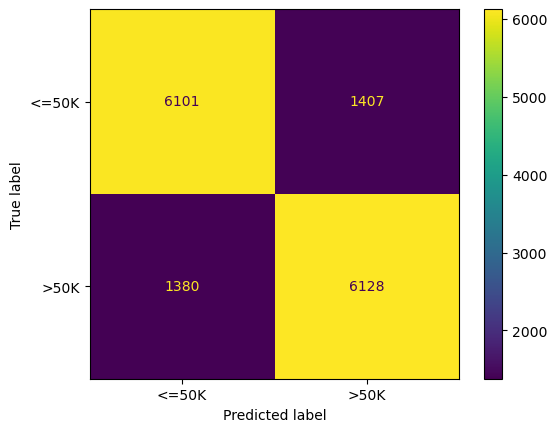

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Visualize OOB predictions using a confusion matrix
cm = confusion_matrix(y, oob_preds['Label'])
cmd = ConfusionMatrixDisplay(cm, display_labels = le.classes_)
cmd.plot();